#Financial Distress & Household Debt Stress Prediction

## EDA

### 1. Libraries and Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set global visualization style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
palette = 'viridis'

In [ ]:
#reading dataset
df = pd.read_csv('credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


### 2. Data Inspection (Shape, Nulls, Describe)

In [ ]:
print(f"Dataset Shape: {df.shape}")
print("\nMissing Values per Column:")
print(df.isnull().sum())

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (32581, 12)

Missing Values per Column:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Statistical Summary:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


### 3. Combined Univariate Analysis
Exploring the distributions of both Person 1 and Person 2's selected features.

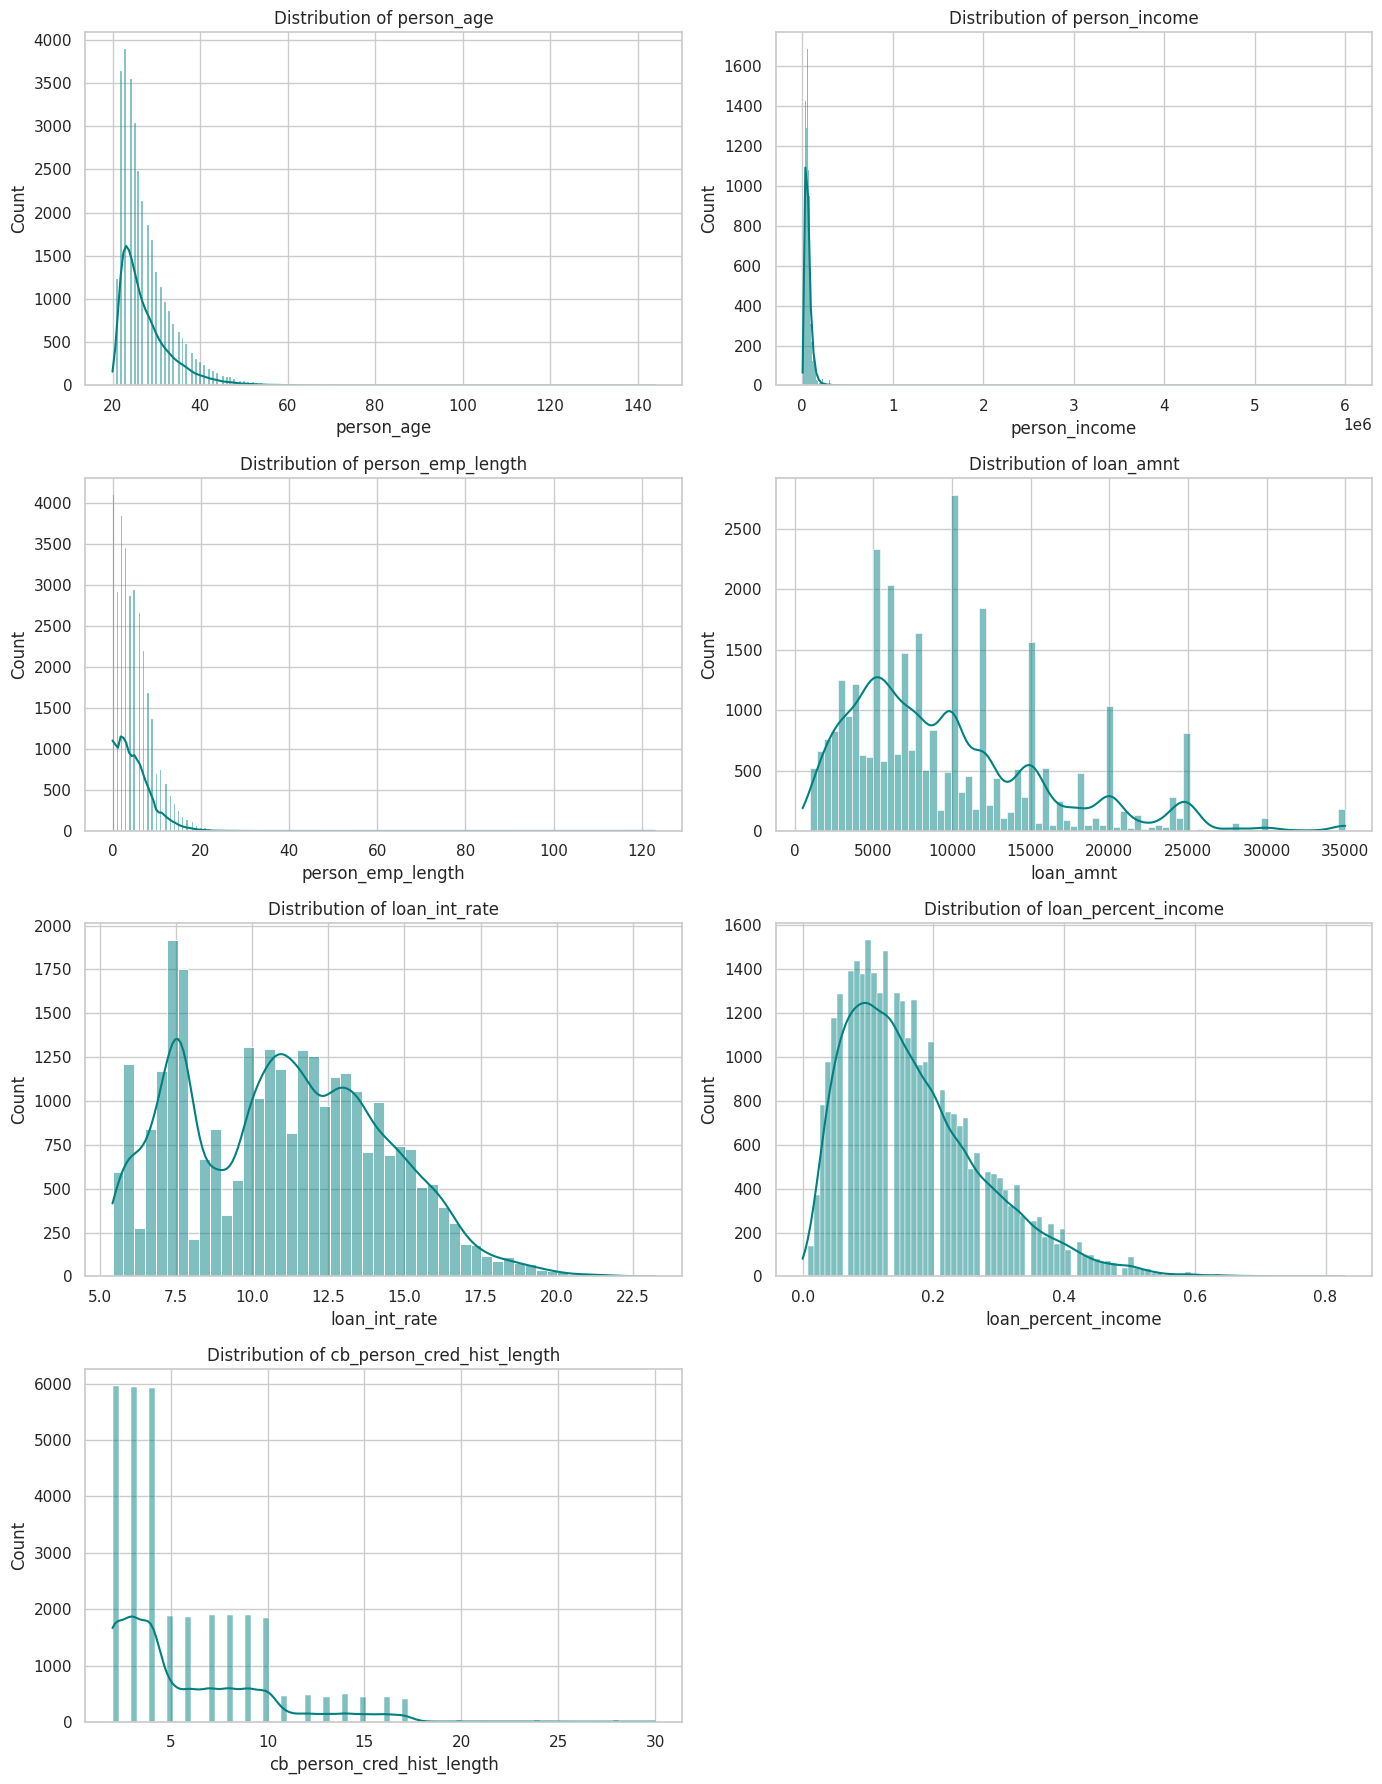

/tmp/ipykernel_572/2918285921.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette=palette, order=df[col].value_counts().index)
/tmp/ipykernel_572/2918285921.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette=palette, order=df[col].value_counts().index)
/tmp/ipykernel_572/2918285921.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette=palette, order=df[col].value_counts().index)
/tmp/ipykernel_572/2918285921.py:29: FutureWarnin

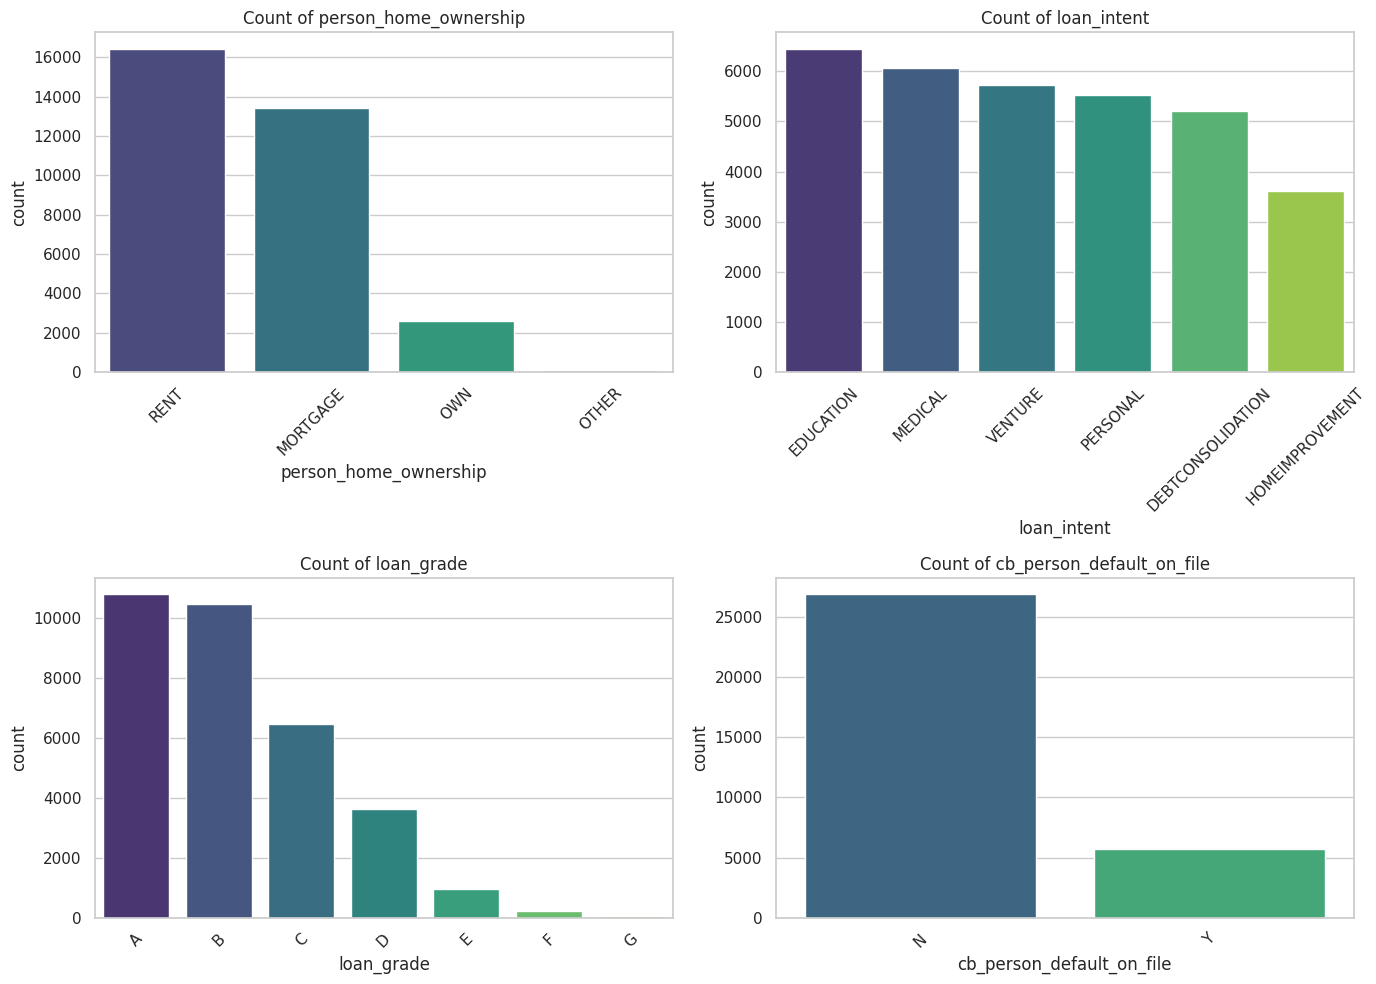

In [ ]:
num_cols = [
    'person_age', 'person_income', 'person_emp_length', 'loan_amnt',
    'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'
]

cat_cols = [
    'person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file'
]

# Numerical Distributions
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)

if len(num_cols) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

# Categorical Distributions
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette=palette, order=df[col].value_counts().index)
    axes[i].set_title(f'Count of {col}', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

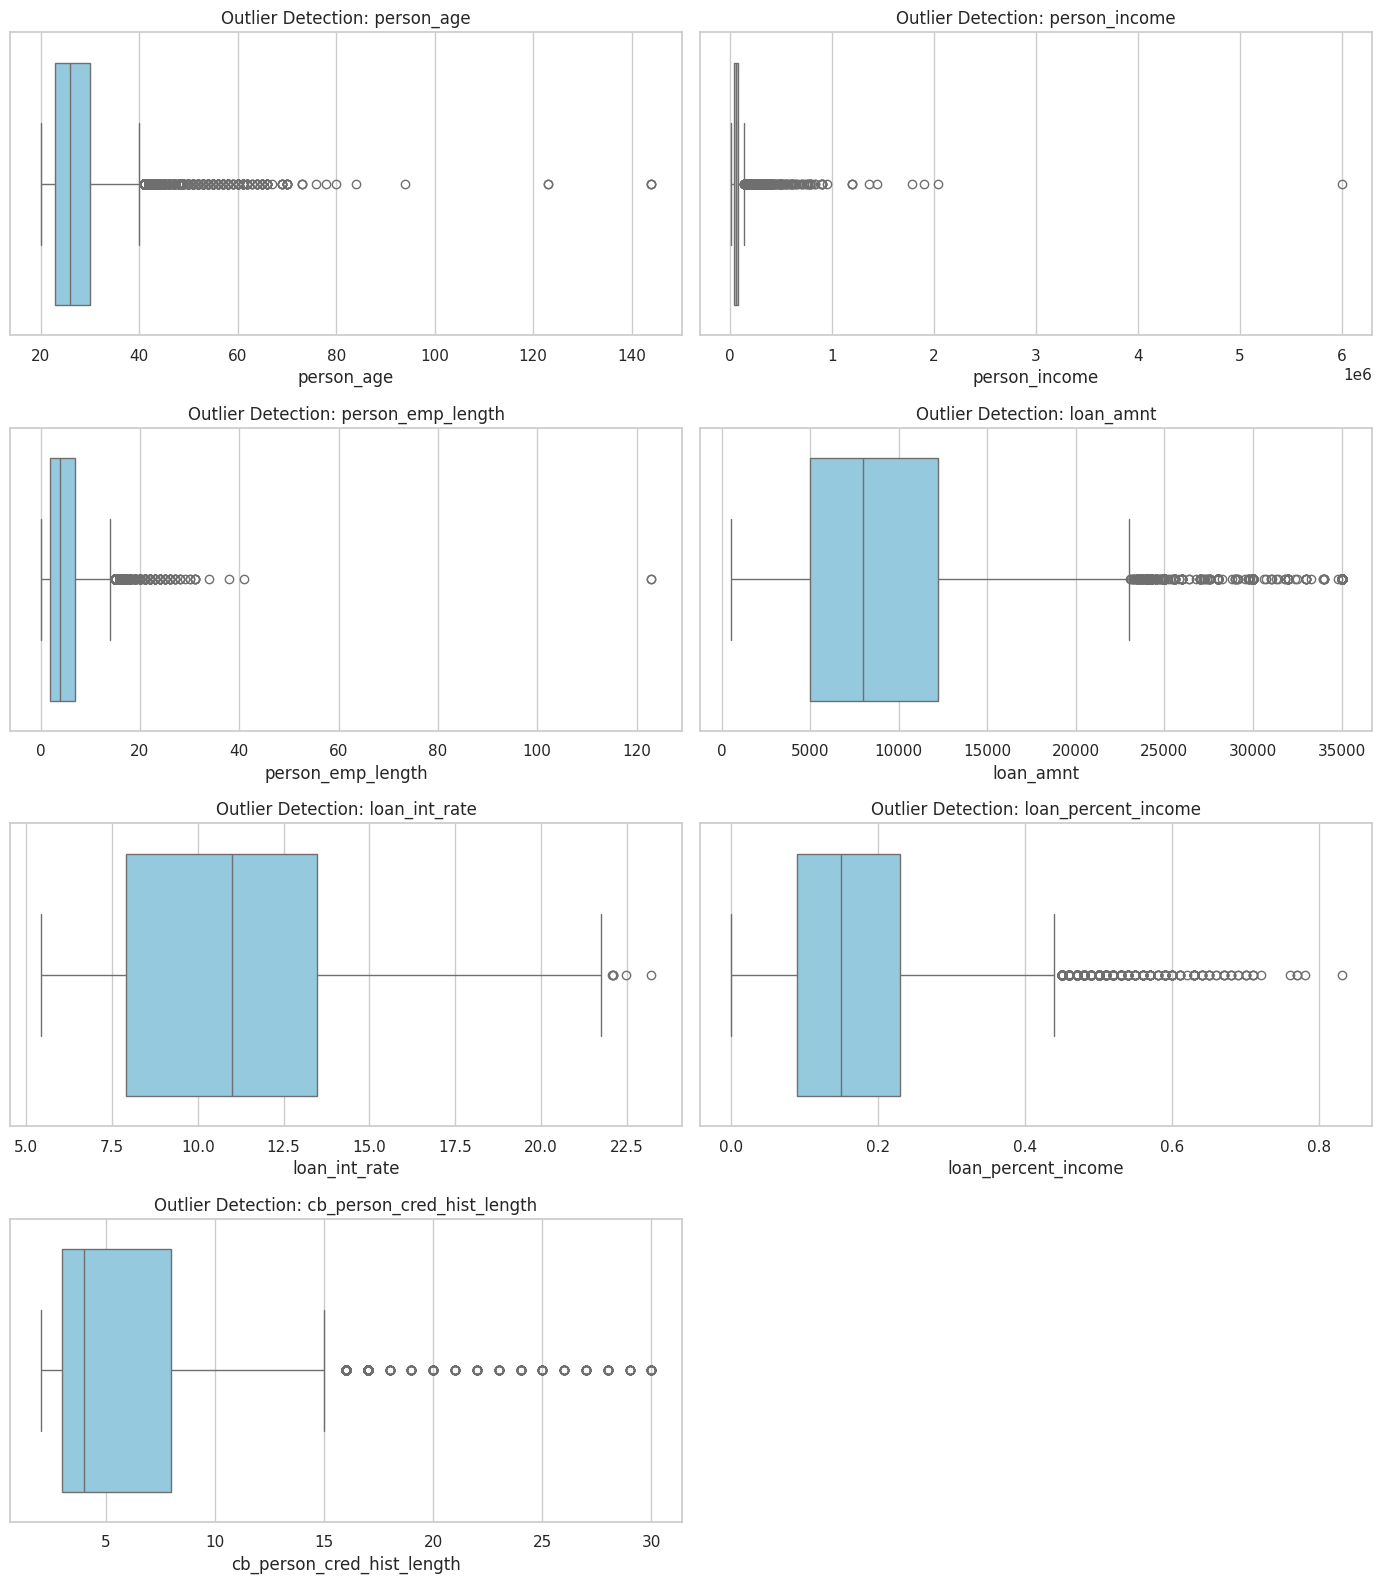

In [ ]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten()
for i, col in enumerate(num_cols):
            sns.boxplot(x=df[col], ax=axes[i], color='skyblue')
            axes[i].set_title(f'Outlier Detection: {col}', fontsize=12)

if len(num_cols) < len(axes): fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

### 4. Combined Bivariate Analysis
Analyzing how features relate to the target variable `loan_status`.

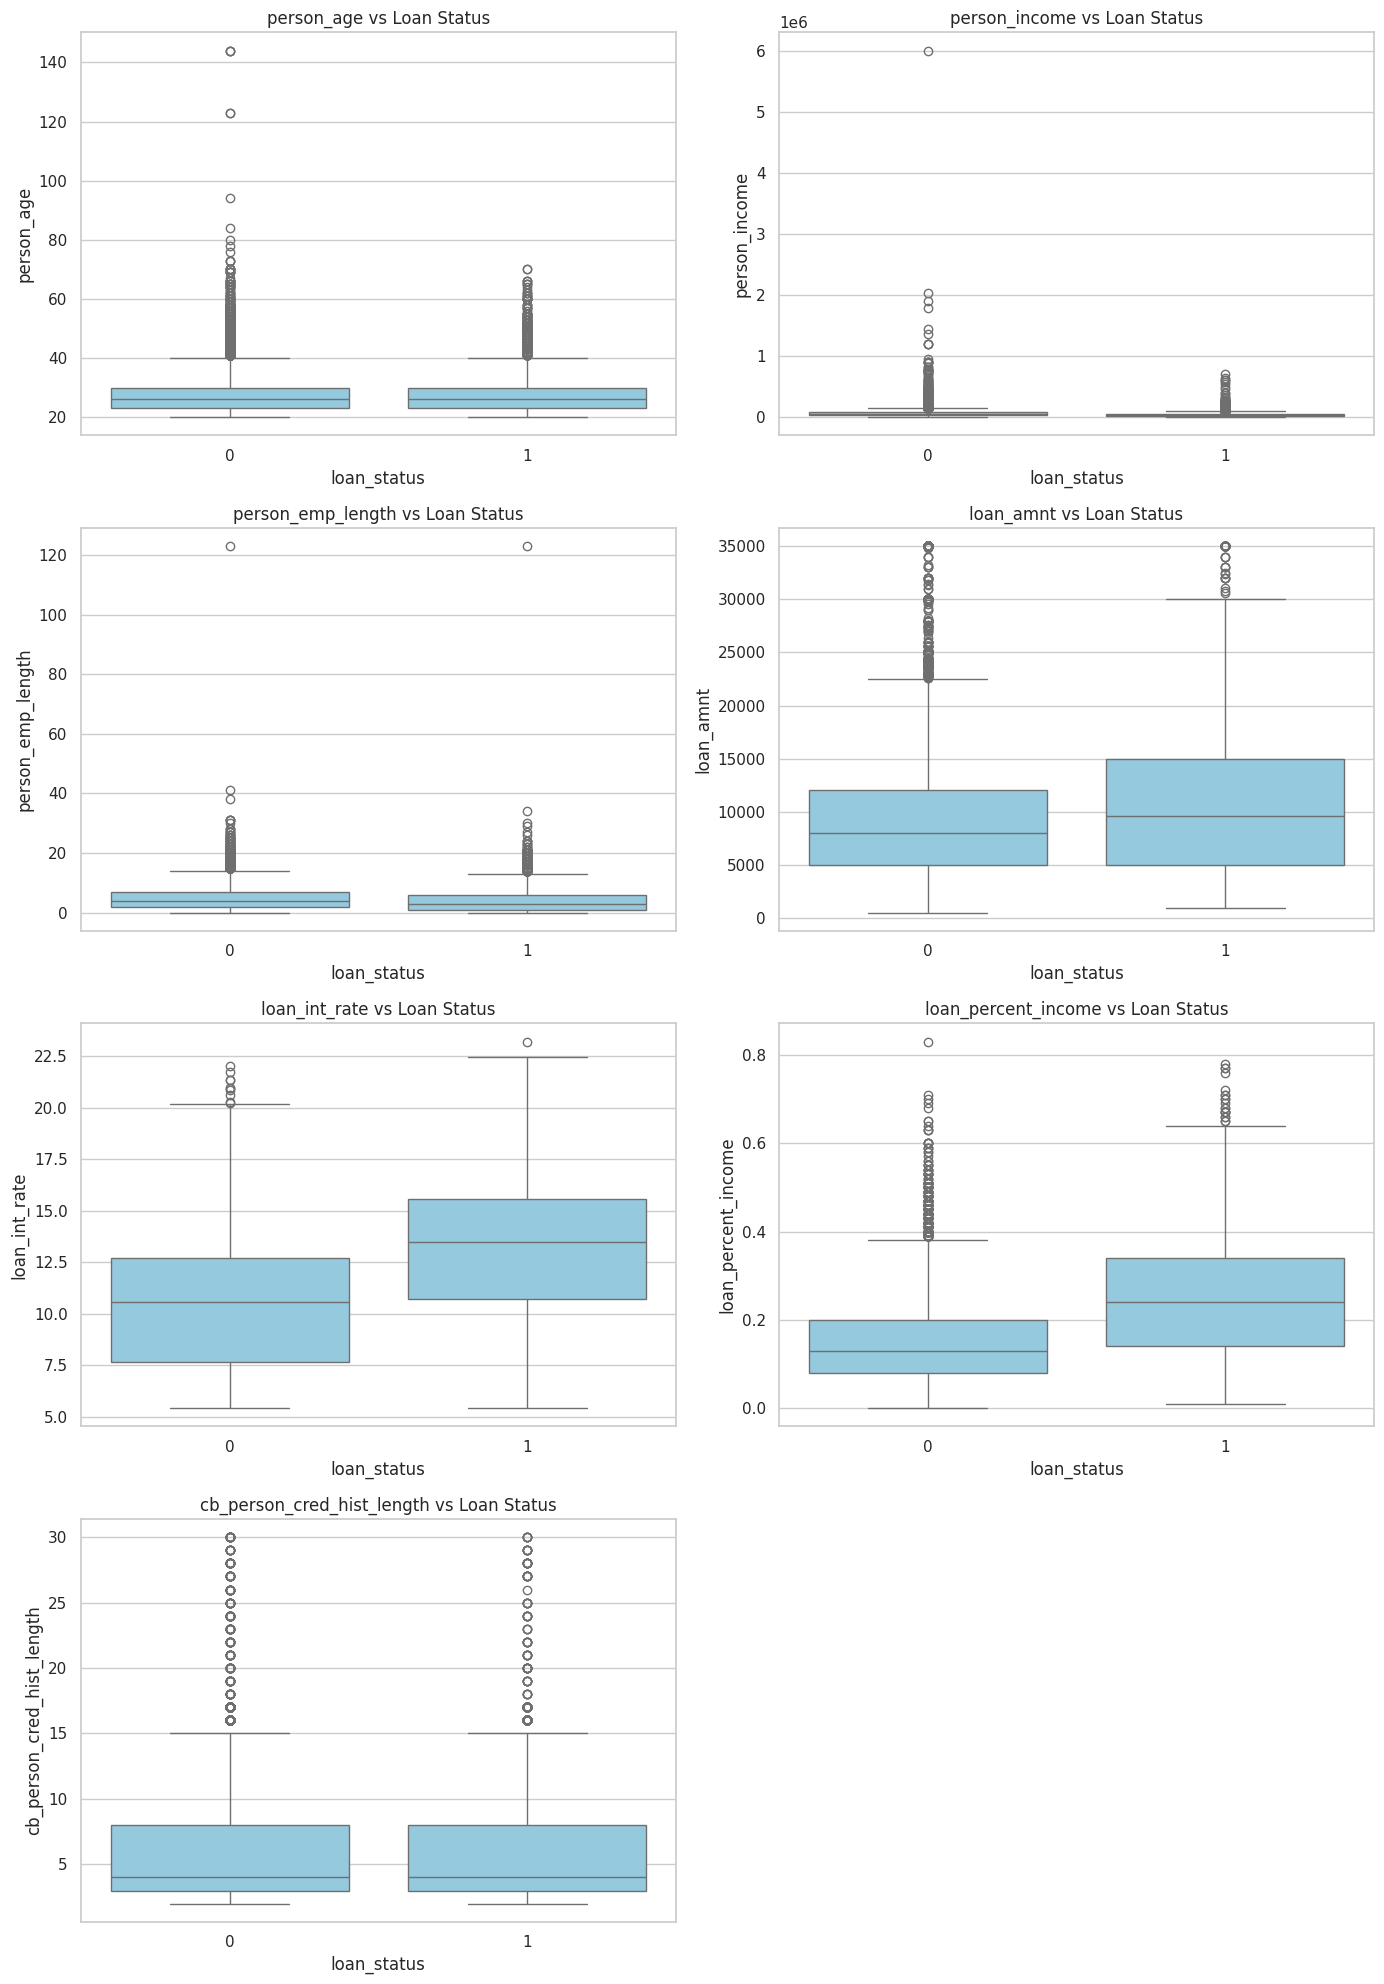

In [ ]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14,20))
axes = axes.flatten()

for i ,col in enumerate(num_cols):
  sns.boxplot(data=df, x='loan_status', y=col, ax=axes[i],color='skyblue')
  axes[i].set_title(f'{col} vs Loan Status', fontsize=12)
if len(num_cols) < len(axes):
   fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

/tmp/ipykernel_572/709660494.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='loan_status', y=col, ax=axes[i], palette='Set2', split=False)
/tmp/ipykernel_572/709660494.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='loan_status', y=col, ax=axes[i], palette='Set2', split=False)
/tmp/ipykernel_572/709660494.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='loan_status', y=col, ax=axes[i], palette='Set2', split=False)
/tmp/ipykernel_572/709660494.py:6: FutureWarning: 

Passing `palette` wit

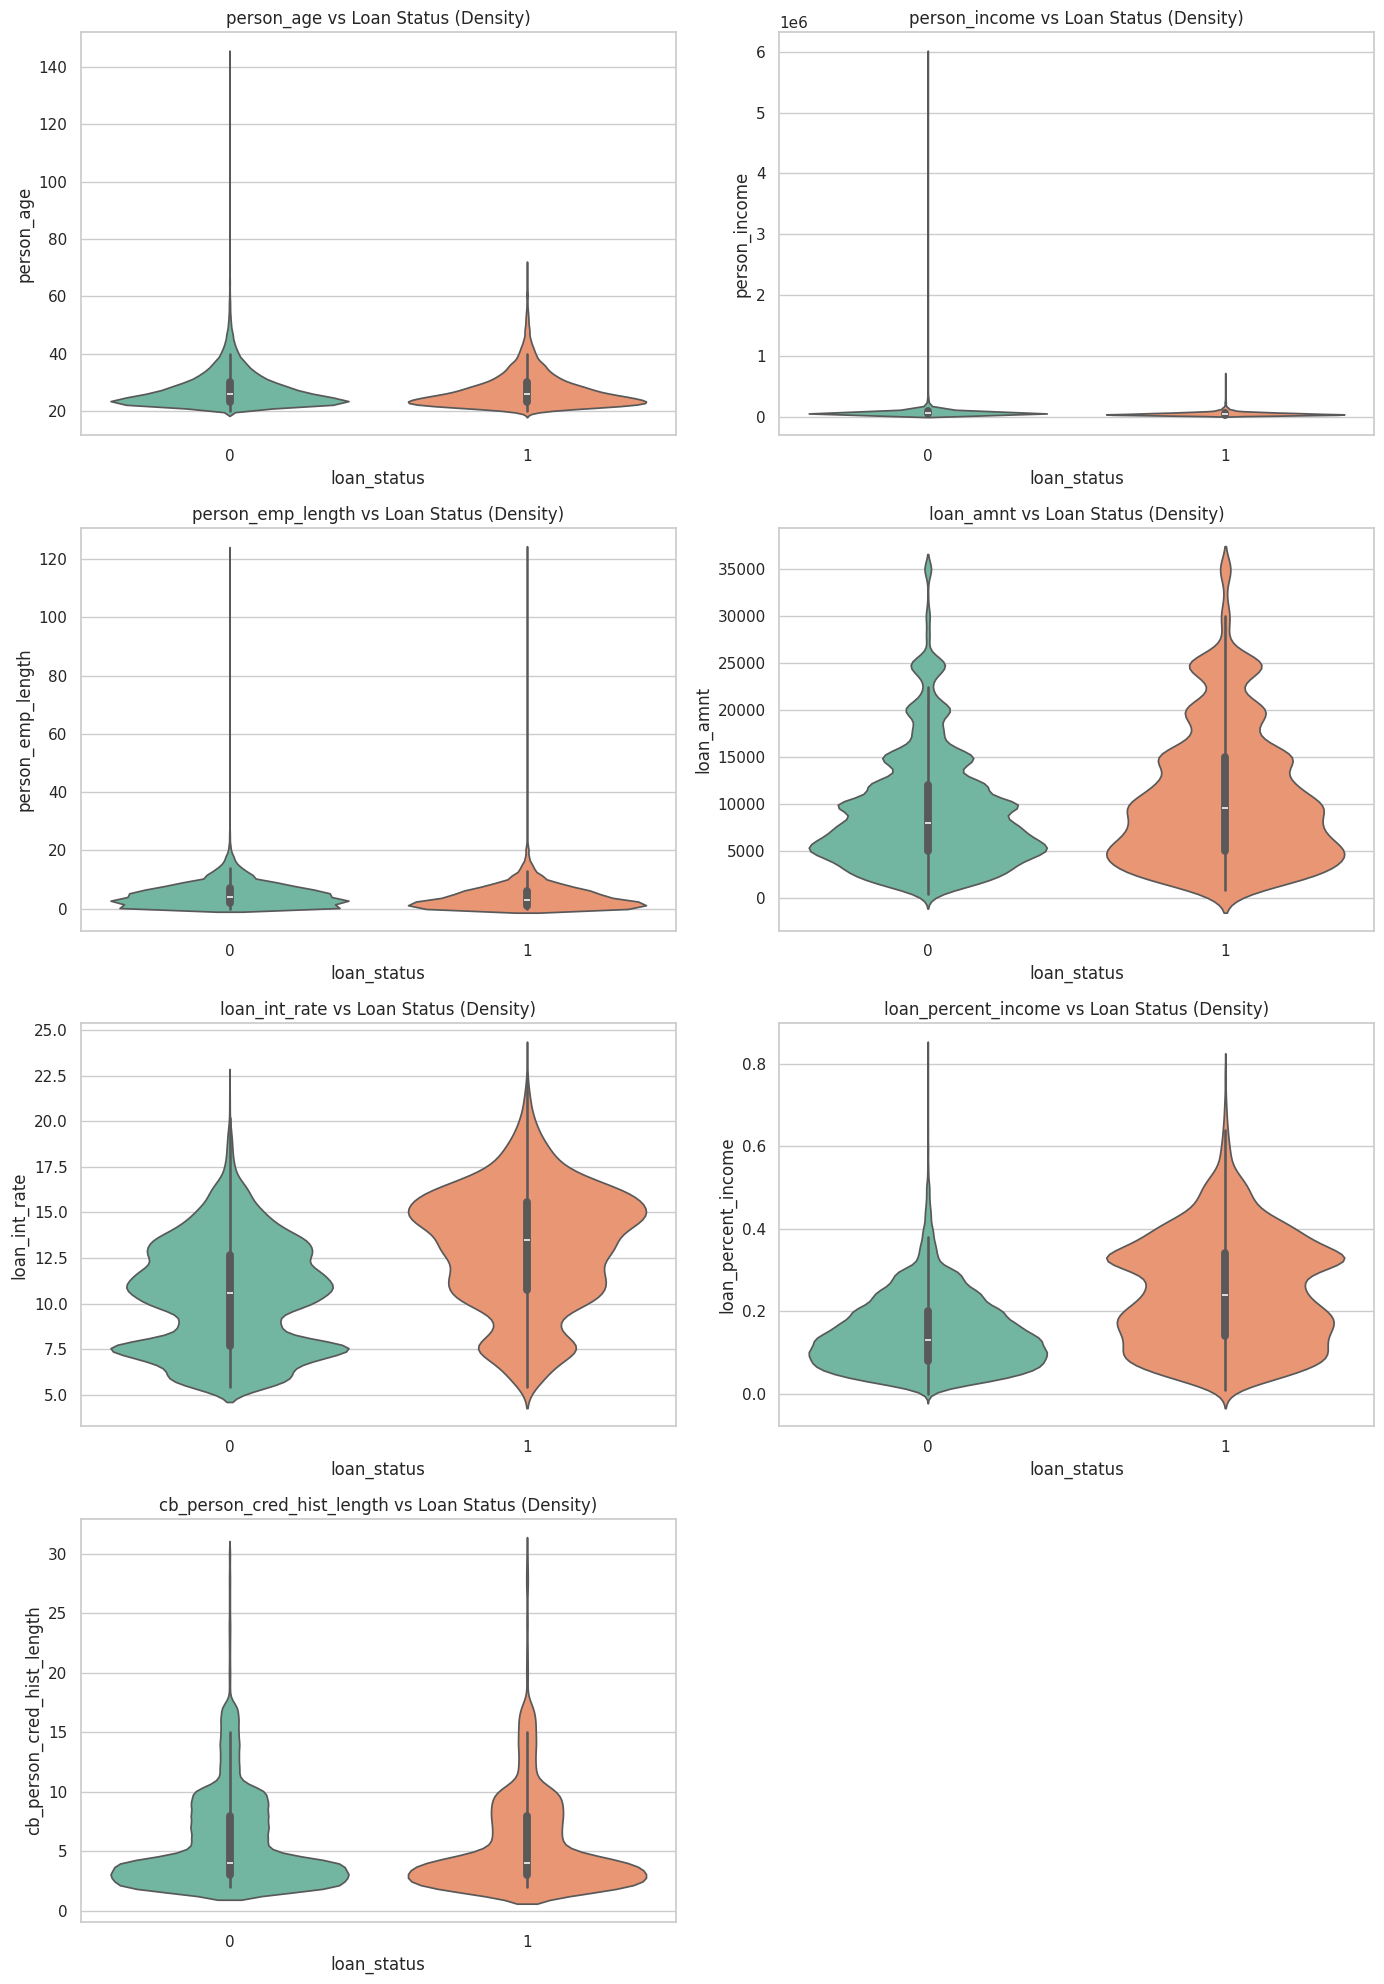

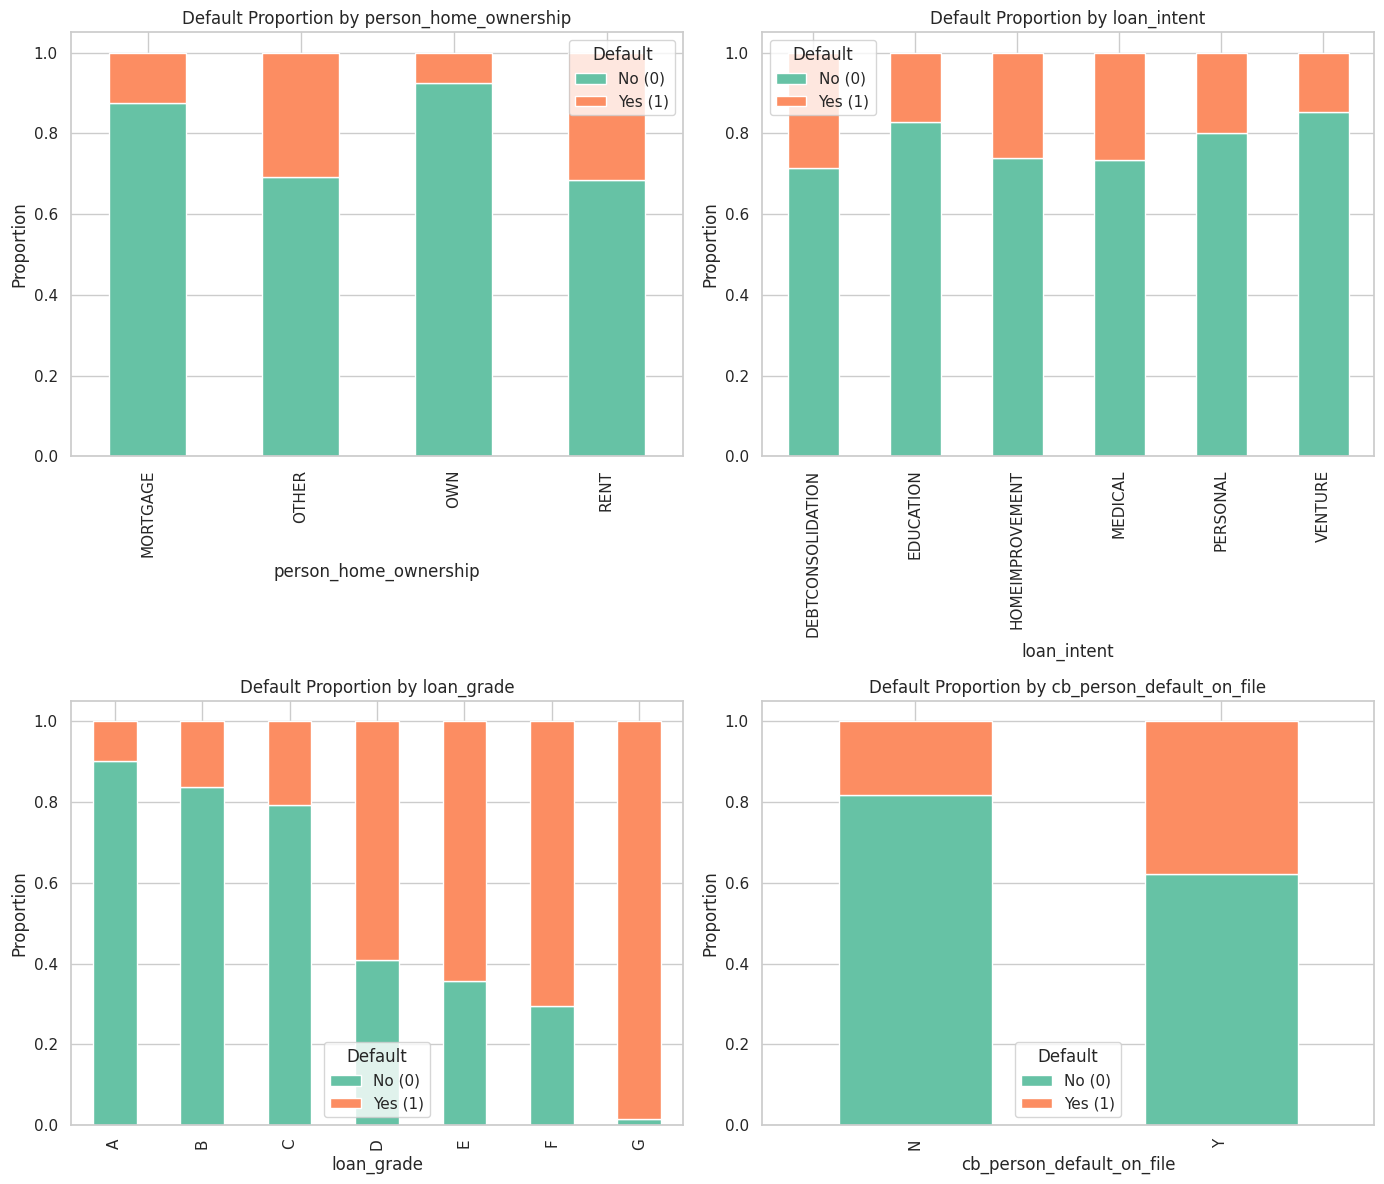

In [ ]:
# Numerical vs. Loan Status (Violin Plots)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.violinplot(data=df, x='loan_status', y=col, ax=axes[i], palette='Set2', split=False)
    axes[i].set_title(f'{col} vs Loan Status (Density)', fontsize=12)

if len(num_cols) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

# Categorical vs. Loan Status (Normalized Stacked Bars)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    prop_df = df.groupby(col)['loan_status'].value_counts(normalize=True).unstack()
    prop_df.plot(kind='bar', stacked=True, ax=axes[i], color=['#66c2a5', '#fc8d62'])
    axes[i].set_title(f'Default Proportion by {col}', fontsize=12)
    axes[i].set_ylabel('Proportion')
    axes[i].legend(title='Default', labels=['No (0)', 'Yes (1)'])

plt.tight_layout()
plt.show()

### 5. Summary of Key Findings

**Data Health & Structure**
* The dataset contains **32,581 records**.
* Missing values are present in `person_emp_length` (895) and `loan_int_rate` (3,116).
* The target variable `loan_status` is imbalanced, with roughly **21.8%** of the dataset representing defaults.

**Statistical Insights**
* **Strong Numerical Indicators:** Both `loan_int_rate` and `loan_percent_income` show clear shifts in distribution for defaulters. Defaulters typically have higher interest rates and higher loan-to-income ratios.
* **Strong Categorical Indicators:** `loan_grade` is highly predictive; as grades move from A toward G, the default probability increases significantly.
* **Lower Variance Features:** `person_age` and `cb_person_cred_hist_length` show very similar medians and distributions for both groups, suggesting lower predictive power in isolation.

## Preprocessing

### Handling Missing Value

In [ ]:
# Impute person_emp_length with median
emp_median = df['person_emp_length'].median()
df['person_emp_length'].fillna(emp_median,inplace=True)
# Impute loan_int_rate with median
rate_median = df['loan_int_rate'].median()
df['loan_int_rate'].fillna(rate_median,inplace=True)
print(f'person_emp_length: imputed 895 nulls with median = {emp_median:.1f} years')
print(f'loan_int_rate: imputed 3116 nulls with median = {rate_median:.2f}%')

person_emp_length: imputed 895 nulls with median = 4.0 years
loan_int_rate: imputed 3116 nulls with median = 10.99%


/tmp/ipykernel_572/2512541646.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['person_emp_length'].fillna(emp_median,inplace=True)
/tmp/ipykernel_572/2512541646.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

- `loan_int_rate` Since the skewness was minimal, the difference between mean and median is negligible, so the choice does not significantly impact model performance.


In [ ]:
# Verify — no more missing values
print('Missing values AFTER imputation:')
print(df.isnull().sum())
print('\nAll null values are handled')

Missing values AFTER imputation:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

All null values are handled


### Outlier Handling

In [ ]:
print('Values BEFORE capping:')
print(f'  person_age        max = {df["person_age"].max():.0f}')
print(f'  person_emp_length max = {df["person_emp_length"].max():.0f}')
print(f'  person_income     max = {df["person_income"].max():,.0f}')

Values BEFORE capping:
  person_age        max = 144
  person_emp_length max = 123
  person_income     max = 6,000,000


In [ ]:
df['person_age'] = df['person_age'].clip(upper=100)
df['person_emp_length'] = df['person_emp_length'].clip(upper=60)

In [ ]:
cap = df['person_income'].quantile(0.99) # Cap person_income at 99th percentile
df['person_income'] = df['person_income'].clip(upper=cap)
df['person_income'] = np.log1p(df['person_income']) # Log transform

/tmp/ipykernel_572/2061397.py:2: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['person_income'] = df['person_income'].clip(upper=cap)


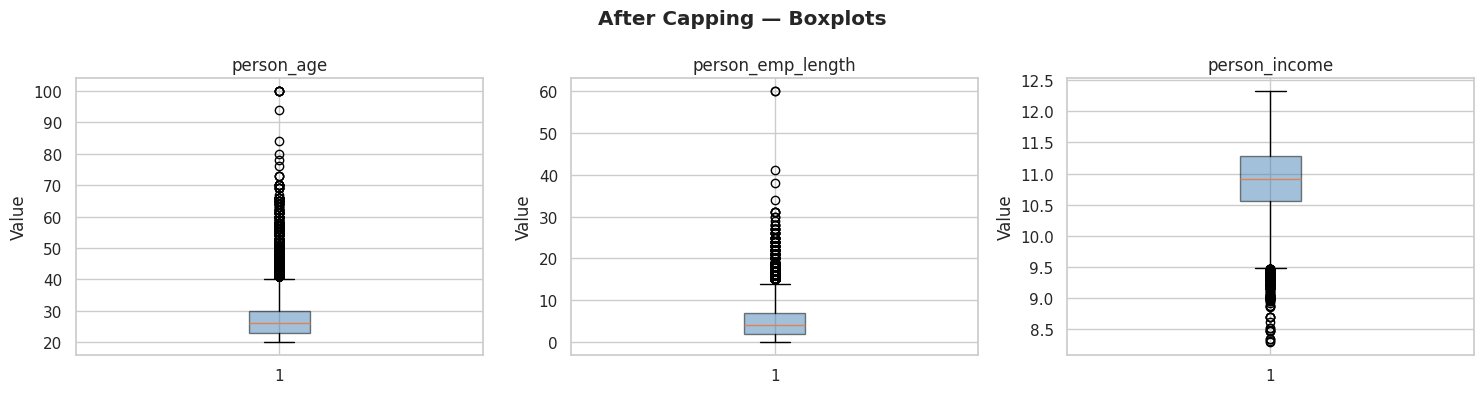

Outliers handled — distributions look clean


In [ ]:
# Visualise after capping — confirm outliers are gone
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('After Capping — Boxplots', fontweight='bold')

for i, col in enumerate(['person_age', 'person_emp_length', 'person_income']):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.5))
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.show()

print('Outliers handled — distributions look clean')

In [ ]:
print('Values AFTER capping:')
print(f'  person_age        max = {df["person_age"].max():.0f}   (capped at 100)')
print(f'  person_emp_length max = {df["person_emp_length"].max():.0f}    (capped at 60)')
print(f'  person_income     max = {df["person_income"].max():.3f}  (log transformed)')
print(f'\nNot capped:')
print(f'  loan_amnt         max = {df["loan_amnt"].max():,.0f}  (plausible real value )')
print(f'  loan_int_rate     max = {df["loan_int_rate"].max():.2f}   (realistic interest rate)')
print(f'  loan_percent_income max = {df["loan_percent_income"].max():.2f}  (valid ratio)')
print(f'  cred_hist_length  max = {df["cb_person_cred_hist_length"].max():.0f}    (30 years — realistic)')

Values AFTER capping:
  person_age        max = 100   (capped at 100)
  person_emp_length max = 60    (capped at 60)
  person_income     max = 12.325  (log transformed)

Not capped:
  loan_amnt         max = 35,000  (plausible real value )
  loan_int_rate     max = 23.22   (realistic interest rate)
  loan_percent_income max = 0.83  (valid ratio)
  cred_hist_length  max = 30    (30 years — realistic)


### Encoding

In [ ]:
# Check all categorical columns before encoding
print('Categorical columns BEFORE encoding:')
cat_cols = ['cb_person_default_on_file', 'loan_grade',
            'person_home_ownership', 'loan_intent']
for col in cat_cols:
    print(f'\n  {col}:')
    print(f'    {df[col].value_counts().to_dict()}')

Categorical columns BEFORE encoding:

  cb_person_default_on_file:
    {'N': 26836, 'Y': 5745}

  loan_grade:
    {'A': 10777, 'B': 10451, 'C': 6458, 'D': 3626, 'E': 964, 'F': 241, 'G': 64}

  person_home_ownership:
    {'RENT': 16446, 'MORTGAGE': 13444, 'OWN': 2584, 'OTHER': 107}

  loan_intent:
    {'EDUCATION': 6453, 'MEDICAL': 6071, 'VENTURE': 5719, 'PERSONAL': 5521, 'DEBTCONSOLIDATION': 5212, 'HOMEIMPROVEMENT': 3605}


In [ ]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split

In [ ]:
# LabelEncoder — cb_person_default_on_file
# Binary column: Y → 1, N → 0
# Person 2 EDA: 'Binary variable — will encode Y=1, N=0'

le = LabelEncoder()
df['cb_person_default_on_file'] = le.fit_transform(df['cb_person_default_on_file'])

print('LabelEncoder — cb_person_default_on_file')
print(f'  Classes : {le.classes_}')
print(f'  Mapping : N=0, Y=1')
print(f'  Result  :')
print(f'  {df["cb_person_default_on_file"].value_counts().to_dict()}')

LabelEncoder — cb_person_default_on_file
  Classes : ['N' 'Y']
  Mapping : N=0, Y=1
  Result  :
  {0: 26836, 1: 5745}


In [ ]:
# OrdinalEncoder — loan_grade
# Ordered: A=1 (best) → G=7 (worst)

GRADE_ORDER = [['A', 'B', 'C', 'D', 'E', 'F', 'G']]
oe = OrdinalEncoder(categories=GRADE_ORDER)
df['loan_grade'] = oe.fit_transform(df[['loan_grade']])
df['loan_grade'] = df['loan_grade'].astype(int) + 1
# +1 so encoding starts at 1 not 0 (A=1, B=2 ... G=7)

print('OrdinalEncoder — loan_grade')
print('  Mapping: A=1, B=2, C=3, D=4, E=5, F=6, G=7')



OrdinalEncoder — loan_grade
  Mapping: A=1, B=2, C=3, D=4, E=5, F=6, G=7
  Result  :


In [ ]:
# OneHotEncoder — person_home_ownership
# Nominal: RENT / OWN / MORTGAGE / OTHER


print('BEFORE OneHotEncoding — person_home_ownership:')
print(df['person_home_ownership'].value_counts())

ohe1 = OneHotEncoder(sparse_output=False, drop='first')
home_encoded = ohe1.fit_transform(df[['person_home_ownership']])
home_cols    = ohe1.get_feature_names_out(['person_home_ownership'])
home_df      = pd.DataFrame(home_encoded, columns=home_cols, index=df.index)

print(f'\nNew columns created: {list(home_cols)}')
print('(OWN is dropped as reference category)')
print('\nSample:')
print(home_df.head(3))

BEFORE OneHotEncoding — person_home_ownership:
person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

New columns created: ['person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT']
(OWN is dropped as reference category)

Sample:
   person_home_ownership_OTHER  person_home_ownership_OWN  \
0                          0.0                        0.0   
1                          0.0                        1.0   
2                          0.0                        0.0   

   person_home_ownership_RENT  
0                         1.0  
1                         0.0  
2                         0.0  


In [ ]:
# OneHotEncoder — loan_intent
# Nominal: 6 categories, no natural order
# EDUCATION / MEDICAL / VENTURE / PERSONAL / DEBTCONSOLIDATION / HOMEIMPROVEMENT

print('BEFORE OneHotEncoding — loan_intent:')
print(df['loan_intent'].value_counts())

ohe2 = OneHotEncoder(sparse_output=False, drop='first')
intent_encoded = ohe2.fit_transform(df[['loan_intent']])
intent_cols    = ohe2.get_feature_names_out(['loan_intent'])
intent_df      = pd.DataFrame(intent_encoded, columns=intent_cols, index=df.index)

print(f'\nNew columns created: {list(intent_cols)}')
print('(DEBTCONSOLIDATION dropped as reference category)')
print('\nSample:')
print(intent_df.head(3))

BEFORE OneHotEncoding — loan_intent:
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

New columns created: ['loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']
(DEBTCONSOLIDATION dropped as reference category)

Sample:
   loan_intent_EDUCATION  loan_intent_HOMEIMPROVEMENT  loan_intent_MEDICAL  \
0                    0.0                          0.0                  0.0   
1                    1.0                          0.0                  0.0   
2                    0.0                          0.0                  1.0   

   loan_intent_PERSONAL  loan_intent_VENTURE  
0                   1.0                  0.0  
1                   0.0                  0.0  
2                   0.0                  0.0  


In [ ]:
df_final = df.drop(columns=['person_home_ownership', 'loan_intent'])

# Add OneHot encoded columns
df_final = pd.concat([df_final, home_df, intent_df], axis=1)

In [ ]:
df_final.head()

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22,10.985310,60.0,4,35000,16.02,1,0.59,1,3,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,21,9.169623,5.0,2,1000,11.14,0,0.10,0,2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,25,9.169623,1.0,3,5500,12.87,1,0.57,0,3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,23,11.089821,4.0,3,35000,15.23,1,0.53,0,2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,24,10.904138,8.0,3,35000,14.27,1,0.55,1,4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


### Scailing and Train test split

In [ ]:
X = df.drop(columns=['loan_status','person_home_ownership', 'loan_intent'])
y = df['loan_status']

In [ ]:
X.head()

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,10.985310,60.0,4,35000,16.02,0.59,1,3
1,21,9.169623,5.0,2,1000,11.14,0.10,0,2
2,25,9.169623,1.0,3,5500,12.87,0.57,0,3
3,23,11.089821,4.0,3,35000,15.23,0.53,0,2
4,24,10.904138,8.0,3,35000,14.27,0.55,1,4


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[[	'person_age','person_income'  ,'person_emp_length','loan_grade','loan_amnt'	,'loan_int_rate',	'loan_percent_income'	,'cb_person_cred_hist_length']])
X_scaled = pd.DataFrame(X_scaled, columns= ['person_age','person_income'  ,'person_emp_length','loan_grade','loan_amnt'	,'loan_int_rate',	'loan_percent_income'	,'cb_person_cred_hist_length'])

In [ ]:
X_scaled.head()

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
0,-0.913929,0.116478,13.793784,1.527718,4.019404,1.625921,3.931411,-0.691554
1,-1.073452,-3.172217,0.058904,-0.187080,-1.358650,0.042310,-0.657458,-0.938167
2,-0.435360,-3.172217,-0.939997,0.670319,-0.646849,0.603713,3.744110,-0.691554
3,-0.754406,0.305775,-0.190822,0.670319,4.019404,1.369558,3.369508,-0.938167
4,-0.594883,-0.030546,0.808079,0.670319,4.019404,1.058028,3.556809,-0.444942


In [ ]:
X_binary =  df[['cb_person_default_on_file']].copy()

In [ ]:
X_final = pd.concat([X_scaled, X_binary,home_df, intent_df ], axis=1)

In [ ]:
X_final.head()

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,cb_person_default_on_file,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,-0.913929,0.116478,13.793784,1.527718,4.019404,1.625921,3.931411,-0.691554,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,-1.073452,-3.172217,0.058904,-0.187080,-1.358650,0.042310,-0.657458,-0.938167,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,-0.435360,-3.172217,-0.939997,0.670319,-0.646849,0.603713,3.744110,-0.691554,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,-0.754406,0.305775,-0.190822,0.670319,4.019404,1.369558,3.369508,-0.938167,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,-0.594883,-0.030546,0.808079,0.670319,4.019404,1.058028,3.556809,-0.444942,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
X_final.dtypes.value_counts()

,count
float64,16
int64,1


### Baseline Model - Logistic Regressor

In [ ]:
from sklearn.linear_model import LogisticRegression
X_train,X_test,y_train,y_test = train_test_split(X_final,y,test_size=0.2,random_state=42,stratify=y)
lr = LogisticRegression(max_iter=1000,class_weight='balanced')
lr.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
lr_y_pred = lr.predict(X_test)
lr_y_prob = lr.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix,roc_auc_score
print(f'Accuracy: {accuracy_score(y_test, lr_y_pred):.2f}')
print(f'Precision: {precision_score(y_test, lr_y_pred):.2f}')
print(f'Recall: {recall_score(y_test, lr_y_pred):.2f}')
print(f'F1 Score: {f1_score(y_test, lr_y_pred):.2f}')
print(f'ROC AUC Score: {roc_auc_score(y_test, lr_y_prob):.2f}')

Accuracy: 0.79
Precision: 0.52
Recall: 0.80
F1 Score: 0.63
ROC AUC Score: 0.87


In [ ]:
print(confusion_matrix(y_test, lr_y_pred))

[[4042 1053]
 [ 290 1132]]
